# Pipeline Evaluation: EfficientNet\_B3 → PGA-UNet

Đánh giá pipeline 2 tầng trên tập `dataset_online` (ảnh có bệnh + ảnh bình thường).

## Cấu trúc dataset_online
```
dataset_online/
  images/          ← tất cả ảnh (.png), cả normal lẫn pathological
  annotations/     ← chỉ ảnh có bệnh mới có file .json
```

## Luồng pipeline
```
Tất cả ảnh → EfficientNet_B3 → Có bệnh? ──Có──→ PGA-UNet (zoom_out prompt) → Dice/IoU
                                          └─Không→ bỏ qua (không qua PGA)
```

## Cách tính 2 phần kết quả độc lập

### Phần 1 — Phân loại (EfficientNet_B3)
Đánh giá trên toàn bộ ảnh. GT suy từ JSON: có JSON = có bệnh, không có JSON = bình thường.

### Phần 2 — Phân đoạn pipeline (PGA-UNet)
Chỉ tính trên ảnh classifier gửi cho PGA (predicted positive = TP + FP).

| Trường hợp | JSON? | Dự đoán | PGA chạy? | Dice/IoU | Vào mẫu số? |
|---|---|---|---|---|---|
| TP | Có | Có bệnh ✅ | Có | Thực tế | ✅ |
| FP | Không | Có bệnh ❌ | Không (no JSON) | **0** | ✅ |
| FN | Có | Không bệnh ❌ | Không | — | ❌ không qua PGA |
| TN | Không | Không bệnh ✅ | Không | — | ❌ |

```
Pipeline_Dice = Σ Dice_i / N_predicted_positive   (TP→Dice thực, FP→0)
```
FP không có JSON nên không có GT mask → Dice=0 gán trực tiếp (không cần chạy PGA).  
FN không qua PGA → không tính vào metric phân đoạn.

In [5]:
# ── Cell 1: Setup ─────────────────────────────────────────────────────────────
%cd /kaggle/working
import os, torch
print('CUDA:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))

# Clone PGA-UNet source
if not os.path.exists('Prompt-Guided-XRay-Segmentation'):
    !git clone -b TN_B_ON https://github.com/ThongLuc2k3/Prompt-Guided-XRay-Segmentation.git

!pip install -q gdown tqdm opencv-python scipy

# Download dataset_online
!gdown 1MWuP7AmdmM9--3M5NXzD7u37lHBzey-k -O dataset_online.zip -q
!unzip -oq dataset_online.zip

print('\n✅ Setup xong')

/kaggle/working
CUDA: True
GPU: Tesla T4

✅ Setup xong


In [6]:
# ── Cell 2: Download checkpoints ──────────────────────────────────────────────
import gdown

CLS_CKPT_ID = '1QWRcLrbmnk1yvvAlVOL__yjGJyoCkmvb'
PGA_CKPT_ID = '1sSoQ8SObteWETuKSsGGhBASPtXQz9JbY'

os.makedirs('/kaggle/working/checkpoints', exist_ok=True)
os.makedirs('/kaggle/working/Prompt-Guided-XRay-Segmentation/checkpoints', exist_ok=True)

cls_ckpt = '/kaggle/working/checkpoints/best_efficientnet_b3.pth'
pga_ckpt = '/kaggle/working/Prompt-Guided-XRay-Segmentation/checkpoints/pga_unet_expB_best.pth'

if not os.path.exists(cls_ckpt):
    gdown.download(f'https://drive.google.com/uc?id={CLS_CKPT_ID}', cls_ckpt, quiet=False)
if not os.path.exists(pga_ckpt):
    gdown.download(f'https://drive.google.com/uc?id={PGA_CKPT_ID}', pga_ckpt, quiet=False)

assert os.path.exists(cls_ckpt), f'❌ Không tìm thấy: {cls_ckpt}'
assert os.path.exists(pga_ckpt), f'❌ Không tìm thấy: {pga_ckpt}'
print('✅ Checkpoints sẵn sàng')

✅ Checkpoints sẵn sàng


In [7]:
# ── Cell 3: Load models ────────────────────────────────────────────────────────
import sys, torch, torch.nn as nn
from torchvision import models as tv_models
sys.path.insert(0, '/kaggle/working/Prompt-Guided-XRay-Segmentation')
from models.networks.prompt_unet_2D import PGA_UNet

DEVICE        = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
CLS_THRESHOLD = 0.5    # ngưỡng phân loại (nhất quán với EfficientNet_B3.ipynb)
CLS_IMG_SIZE  = 300    # EfficientNet_B3
SEG_IMG_SIZE  = 512    # PGA-UNet

# --- EfficientNet_B3 ---
cls_model = tv_models.efficientnet_b3(weights=None)
cls_model.classifier[1] = nn.Linear(cls_model.classifier[1].in_features, 1)
cls_model.load_state_dict(torch.load(cls_ckpt, map_location=DEVICE, weights_only=True))
cls_model = cls_model.to(DEVICE).eval()
print('✅ EfficientNet_B3 loaded')

# --- PGA-UNet ---
seg_model = PGA_UNet(in_channels=1, n_classes=1, use_encoder_prompt=True).to(DEVICE)
seg_model.load_state_dict(torch.load(pga_ckpt, map_location=DEVICE, weights_only=True))
seg_model.eval()
print('✅ PGA-UNet loaded')

✅ EfficientNet_B3 loaded
✅ PGA-UNet loaded


In [8]:
# ── Cell 4: Helpers ────────────────────────────────────────────────────────────
import cv2, json, numpy as np
from PIL import Image
from torchvision import transforms

# --- Preprocessing ---

cls_transform = transforms.Compose([
    transforms.Resize((CLS_IMG_SIZE, CLS_IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

seg_transform = transforms.Compose([
    transforms.Resize((SEG_IMG_SIZE, SEG_IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5]),
])

def preprocess_cls(img_path):
    img = Image.open(img_path).convert('RGB')
    return cls_transform(img).unsqueeze(0).to(DEVICE)

def preprocess_seg(img_path):
    img = Image.open(img_path).convert('L')
    return seg_transform(img).unsqueeze(0).to(DEVICE)

# --- Per-polygon helpers ---

def load_polygons(json_path):
    with open(json_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    return [s['points'] for s in data.get('shapes', [])
            if s.get('shape_type') == 'polygon']

def polygon_heatmap(polygon_pts, img_path, S=512, zoom_ratio=0.30):
    orig = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    oh, ow = orig.shape[:2]
    pts = np.array(polygon_pts, dtype=np.float32)
    x_min, y_min = np.min(pts, axis=0)
    x_max, y_max = np.max(pts, axis=0)
    gt_w, gt_h = x_max - x_min, y_max - y_min
    bx_min = max(0,  x_min - gt_w * zoom_ratio)
    bx_max = min(ow, x_max + gt_w * zoom_ratio)
    by_min = max(0,  y_min - gt_h * zoom_ratio)
    by_max = min(oh, y_max + gt_h * zoom_ratio)
    hm = np.zeros((oh, ow), dtype=np.float32)
    xi = max(0, int(bx_min - 5)); xa = min(ow, int(bx_max + 5))
    yi = max(0, int(by_min - 5)); ya = min(oh, int(by_max + 5))
    if xa > xi and ya > yi:
        hm[yi:ya, xi:xa] = 1.0
        hm = cv2.GaussianBlur(hm, (31, 31), 0)
    hm = cv2.resize(hm, (S, S))
    return torch.from_numpy(hm).unsqueeze(0).unsqueeze(0).to(DEVICE)

def polygon_gt_mask(polygon_pts, img_path, S=512):
    orig = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    oh, ow = orig.shape[:2]
    pts = np.array(polygon_pts, dtype=np.float32)
    mask = np.zeros((oh, ow), dtype=np.uint8)
    cv2.fillPoly(mask, [pts.astype(np.int32)], 255)
    mask = cv2.resize(mask, (S, S), interpolation=cv2.INTER_NEAREST)
    return (mask > 127).astype(np.float32)

# --- Segmentation metrics ---

def extract_lcc(m):
    if m.sum() == 0: return m
    n, lbl, st, _ = cv2.connectedComponentsWithStats(m.astype(np.uint8), 8)
    return m if n <= 1 else (lbl == (1 + np.argmax(st[1:, cv2.CC_STAT_AREA]))).astype(np.float32)

def calc_dice_iou_img(pred_prob, gt_mask):
    """Image-level: NO LCC (nhieu polygon da duoc max-merge)."""
    pm  = (pred_prob > 0.5).astype(np.float32)
    gm  = (gt_mask   > 0.5).astype(np.float32)
    eps = 1e-6
    tp  = (pm * gm).sum()
    fp  = (pm * (1 - gm)).sum()
    fn  = ((1 - pm) * gm).sum()
    dice = float((2*tp + eps) / (2*tp + fp + fn + eps))
    iou  = float((tp  + eps) / (tp  + fp + fn + eps))
    return dice, iou

print('OK Helpers san sang')

OK Helpers san sang


In [9]:
# ── Cell 5: Chay pipeline tren dataset_online ──────────────────────────────────
from tqdm import tqdm

IMG_DIR  = '/kaggle/working/dataset_online/images'
JSON_DIR = '/kaggle/working/dataset_online/Annotations'

all_images = sorted([f for f in os.listdir(IMG_DIR) if f.lower().endswith(('.png', '.jpeg', '.jpg'))])
json_set   = set(os.path.splitext(f)[0]
                 for f in os.listdir(JSON_DIR) if f.endswith('.json'))

N_total        = len(all_images)
N_pathological = len(json_set)
N_normal       = N_total - N_pathological

print(f'Tong anh       : {N_total}')
print(f'Co benh (JSON) : {N_pathological}')
print(f'Binh thuong    : {N_normal}')
print()

# results     : per-image, dung cho classification metrics
# seg_samples : per-image (TP image-level hoac FP), dung cho pipeline Dice/IoU
#   - TP image -> max-merge cac polygon -> dice/iou image-level
#   - FP image -> dice=0, iou=0 (khong co GT mask)
results     = []
seg_samples = []

cls_model.eval()
seg_model.eval()

with torch.no_grad():
    for img_file in tqdm(all_images, desc='Pipeline'):
        base            = os.path.splitext(img_file)[0]
        img_path        = os.path.join(IMG_DIR,  img_file)
        jsn_path        = os.path.join(JSON_DIR, base + '.json')
        is_pathological = base in json_set

        # -- Tang 1: Phan loai --
        cls_prob   = torch.sigmoid(cls_model(preprocess_cls(img_path))).item()
        pred_label = 1 if cls_prob >= CLS_THRESHOLD else 0
        gt_label   = 1 if is_pathological else 0

        entry = {
            'sample'         : base,
            'gt_label'       : gt_label,
            'pred_label'     : pred_label,
            'cls_prob'       : cls_prob,
            'is_pathological': is_pathological,
        }

        if pred_label == 1:
            if is_pathological:
                # -- TP: max-merge polygon predictions -> image-level metric --
                polygons   = load_polygons(jsn_path)
                gt_img     = np.zeros((SEG_IMG_SIZE, SEG_IMG_SIZE), dtype=np.float32)
                prob_img   = np.zeros((SEG_IMG_SIZE, SEG_IMG_SIZE), dtype=np.float32)
                img_tensor = preprocess_seg(img_path)
                for pts in polygons:
                    gt_mask = polygon_gt_mask(pts, img_path)
                    hm      = polygon_heatmap(pts, img_path)
                    prob_np = torch.sigmoid(
                        seg_model(img_tensor, hm)
                    )[0, 0].cpu().numpy()
                    np.maximum(gt_img,   gt_mask, out=gt_img)
                    np.maximum(prob_img, prob_np, out=prob_img)
                d, u = calc_dice_iou_img(prob_img, gt_img)
                seg_samples.append({'seg_status': 'TP', 'dice': d, 'iou': u, 'img': base})
                entry.update({
                    'seg_status'  : 'TP',
                    'n_polygons'  : len(polygons),
                    'dice'        : d,
                    'iou'         : u,
                })
            else:
                # -- FP: khong co GT -> Dice=0, IoU=0 (1 don vi mau) --
                seg_samples.append({'seg_status': 'FP', 'dice': 0.0, 'iou': 0.0, 'img': base})
                entry.update({'seg_status': 'FP', 'dice': 0.0, 'iou': 0.0, 'n_polygons': 0})
        else:
            if is_pathological:   # FN
                entry.update({'seg_status': 'FN', 'dice': None, 'iou': None, 'n_polygons': None})
            else:                 # TN
                entry.update({'seg_status': 'TN', 'dice': None, 'iou': None, 'n_polygons': 0})

        results.append(entry)

n_tp_samples = sum(1 for s in seg_samples if s['seg_status'] == 'TP')
n_fp_images  = sum(1 for s in seg_samples if s['seg_status'] == 'FP')
print(f'\nOK Hoan thanh {len(results)} anh')
print(f'   TP anh (image-level) : {n_tp_samples}')
print(f'   FP anh               : {n_fp_images}')
print(f'   Tong don vi phan doan: {n_tp_samples + n_fp_images}')

Tong anh       : 375
Co benh (JSON) : 187
Binh thuong    : 188



Pipeline: 100%|██████████| 375/375 [00:39<00:00,  9.61it/s]


OK Hoan thanh 375 anh
   TP anh (image-level) : 166
   FP anh               : 24
   Tong don vi phan doan: 190


  BUOC 1 -- PHAN LOAI (EfficientNet_B3)
  Input : 375 anh  -  Co benh (GT): 187  |  Binh thuong (GT): 188

  Ket qua phan loai:
    Co benh -> du doan Co benh   (TP) :  166 anh  <- dua vao PGA
    Co benh -> du doan Binh thuong(FN):   21 anh  <- bo sot
    Binh thuong -> du doan Co benh(FP):   24 anh  <- dua nham vao PGA -> Dice=0
    Binh thuong -> du doan Binh thuong(TN): 164 anh

  Metrics phan loai:
    Sensitivity (Recall) : 0.8877  - 166/187 anh benh phat hien dung
    Specificity          : 0.8723  - 164/188 anh binh thuong loc dung
    Precision            : 0.8737
    NPV                  : 0.8865
    F1-score             : 0.8806
    Accuracy             : 0.8800
    AUC-ROC              : 0.9405

  BUOC 2 -- DAU VAO PGA-UNet (anh duoc phan loai la Co benh)
  Tong anh dua vao PGA : 166 (TP) + 24 (FP) = 190 anh

  Phan tich 166 anh TP (thuc su co benh):
    -> Tong polygon trong 166 anh TP : 209
    -> Trung binh polygon/anh             : 1.26
    -> Max-merge predictions + un

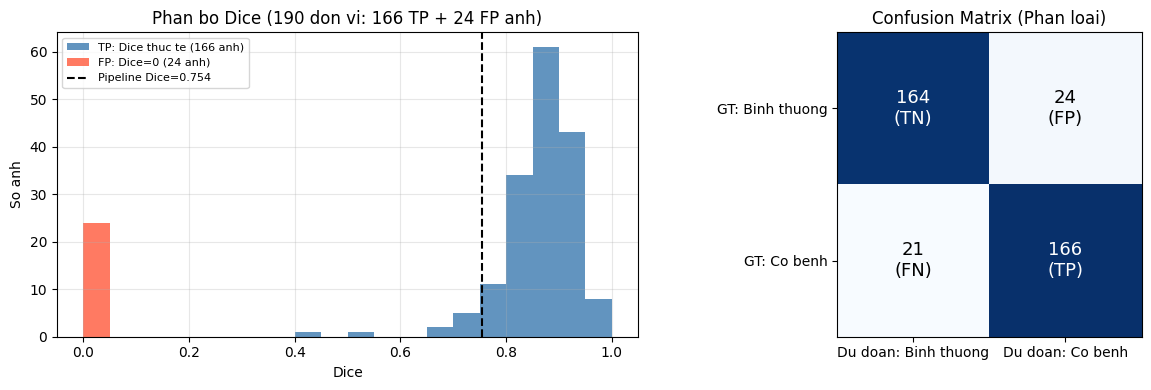

OK Chart saved: results/pipeline_evaluation.png


In [10]:
# ── Cell 6: Ket qua ────────────────────────────────────────────────────────────
import numpy as np, matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, roc_auc_score

# -- Dem tung loai anh --
n_tp_img = sum(1 for r in results if r['seg_status'] == 'TP')
n_fp_img = sum(1 for r in results if r['seg_status'] == 'FP')
n_fn_img = sum(1 for r in results if r['seg_status'] == 'FN')
n_tn_img = sum(1 for r in results if r['seg_status'] == 'TN')

# -- Don vi phan doan (image-level) --
n_tp_samples = sum(1 for s in seg_samples if s['seg_status'] == 'TP')  # = n_tp_img
n_fp_images  = sum(1 for s in seg_samples if s['seg_status'] == 'FP')  # = n_fp_img
n_seg_total  = n_tp_samples + n_fp_images

# ================================================================
# BUOC 1 -- PHAN LOAI (EfficientNet_B3)
# ================================================================
gt_labels   = [r['gt_label']   for r in results]
pred_labels = [r['pred_label'] for r in results]
cls_probs   = [r['cls_prob']   for r in results]

sensitivity = n_tp_img / (n_tp_img + n_fn_img) if (n_tp_img + n_fn_img) > 0 else 0.0
specificity = n_tn_img / (n_tn_img + n_fp_img) if (n_tn_img + n_fp_img) > 0 else 0.0
precision   = n_tp_img / (n_tp_img + n_fp_img) if (n_tp_img + n_fp_img) > 0 else 0.0
npv         = n_tn_img / (n_tn_img + n_fn_img) if (n_tn_img + n_fn_img) > 0 else 0.0
f1          = 2 * precision * sensitivity / (precision + sensitivity + 1e-9)
accuracy    = accuracy_score(gt_labels, pred_labels)
auc         = roc_auc_score(gt_labels, cls_probs)

print('=' * 65)
print('  BUOC 1 -- PHAN LOAI (EfficientNet_B3)')
print('=' * 65)
print(f'  Input : {N_total} anh  -  Co benh (GT): {N_pathological}  |  Binh thuong (GT): {N_normal}')
print()
print(f'  Ket qua phan loai:')
print(f'    Co benh -> du doan Co benh   (TP) : {n_tp_img:>4} anh  <- dua vao PGA')
print(f'    Co benh -> du doan Binh thuong(FN): {n_fn_img:>4} anh  <- bo sot')
print(f'    Binh thuong -> du doan Co benh(FP): {n_fp_img:>4} anh  <- dua nham vao PGA -> Dice=0')
print(f'    Binh thuong -> du doan Binh thuong(TN):{n_tn_img:>4} anh')
print()
print(f'  Metrics phan loai:')
print(f'    Sensitivity (Recall) : {sensitivity:.4f}  - {n_tp_img}/{n_tp_img+n_fn_img} anh benh phat hien dung')
print(f'    Specificity          : {specificity:.4f}  - {n_tn_img}/{n_tn_img+n_fp_img} anh binh thuong loc dung')
print(f'    Precision            : {precision:.4f}')
print(f'    NPV                  : {npv:.4f}')
print(f'    F1-score             : {f1:.4f}')
print(f'    Accuracy             : {accuracy:.4f}')
print(f'    AUC-ROC              : {auc:.4f}')

# ================================================================
# BUOC 2 -- DAU VAO PGA-UNet
# ================================================================
print()
print('=' * 65)
print('  BUOC 2 -- DAU VAO PGA-UNet (anh duoc phan loai la Co benh)')
print('=' * 65)
n_pred_pos     = n_tp_img + n_fp_img
total_polygons = sum(r.get('n_polygons', 0) or 0 for r in results if r.get('seg_status') == 'TP')
print(f'  Tong anh dua vao PGA : {n_tp_img} (TP) + {n_fp_img} (FP) = {n_pred_pos} anh')
print()
print(f'  Phan tich {n_tp_img} anh TP (thuc su co benh):')
print(f'    -> Tong polygon trong {n_tp_img} anh TP : {total_polygons}')
if n_tp_img > 0:
    print(f'    -> Trung binh polygon/anh             : {total_polygons/n_tp_img:.2f}')
print(f'    -> Max-merge predictions + union GT -> 1 metric image-level/anh')
print()
print(f'  Phan tich {n_fp_img} anh FP (binh thuong bi doan sai):')
print(f'    -> Khong co JSON -> Gan Dice=0, IoU=0')
print()
print(f'  Tong don vi phan doan (mau so):')
print(f'    {n_tp_samples} anh(TP) + {n_fp_images} anh(FP) = {n_seg_total} don vi (image-level)')

# ================================================================
# BUOC 3 -- KET QUA PHAN DOAN PIPELINE
# ================================================================
tp_dice_sum = sum(s['dice'] for s in seg_samples if s['seg_status'] == 'TP')
tp_iou_sum  = sum(s['iou']  for s in seg_samples if s['seg_status'] == 'TP')

pipeline_dice = tp_dice_sum / n_seg_total if n_seg_total > 0 else 0.0
pipeline_iou  = tp_iou_sum  / n_seg_total if n_seg_total > 0 else 0.0

tp_dice_vals = [s['dice'] for s in seg_samples if s['seg_status'] == 'TP']

print()
print('=' * 65)
print('  BUOC 3 -- KET QUA PHAN DOAN PIPELINE (PGA-UNet, image-level)')
print('=' * 65)
if tp_dice_vals:
    print(f'  Dice TB TP anh  : {np.mean(tp_dice_vals):.4f}  (chi tinh anh benh dung)')
print(f'  Sigma Dice ({n_tp_samples} anh TP): {tp_dice_sum:.4f}')
print(f'  Sigma IoU  ({n_tp_samples} anh TP): {tp_iou_sum:.4f}')
print()
print(f'  Pipeline Dice = {tp_dice_sum:.4f} / {n_seg_total} = {pipeline_dice:.4f}')
print(f'  Pipeline IoU  = {tp_iou_sum:.4f} / {n_seg_total} = {pipeline_iou:.4f}')

# -- Bieu do --
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

bins = np.linspace(0, 1, 21)
fp_dice_vals = [0.0] * n_fp_images

if tp_dice_vals:
    axes[0].hist(tp_dice_vals, bins=bins, color='steelblue', alpha=0.85,
                 label=f'TP: Dice thuc te ({n_tp_samples} anh)')
if fp_dice_vals:
    axes[0].hist(fp_dice_vals, bins=bins, color='tomato', alpha=0.85,
                 label=f'FP: Dice=0 ({n_fp_images} anh)')
axes[0].axvline(pipeline_dice, color='black', linestyle='--',
                label=f'Pipeline Dice={pipeline_dice:.3f}')
axes[0].set_xlabel('Dice'); axes[0].set_ylabel('So anh')
axes[0].set_title(f'Phan bo Dice ({n_seg_total} don vi: {n_tp_samples} TP + {n_fp_images} FP anh)')
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

cm_val = [[n_tn_img, n_fp_img], [n_fn_img, n_tp_img]]
cm_lbl = [['TN', 'FP'], ['FN', 'TP']]
axes[1].imshow(cm_val, cmap='Blues')
vmax = max(n_tn_img, n_fp_img, n_fn_img, n_tp_img)
for i in range(2):
    for j in range(2):
        axes[1].text(j, i, f'{cm_val[i][j]}\n({cm_lbl[i][j]})',
                     ha='center', va='center', fontsize=13,
                     color='white' if cm_val[i][j] > vmax / 2 else 'black')
axes[1].set_xticks([0, 1]); axes[1].set_yticks([0, 1])
axes[1].set_xticklabels(['Du doan: Binh thuong', 'Du doan: Co benh'])
axes[1].set_yticklabels(['GT: Binh thuong', 'GT: Co benh'])
axes[1].set_title('Confusion Matrix (Phan loai)')

plt.tight_layout()
os.makedirs('results', exist_ok=True)
plt.savefig('results/pipeline_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print('OK Chart saved: results/pipeline_evaluation.png')

In [11]:
# ── Cell 7: Luu CSV + Tom tat ─────────────────────────────────────────────────
import csv

# Luu per-image results (classification + segmentation)
csv_path = 'results/pipeline_detail.csv'
fieldnames = ['sample', 'gt_label', 'pred_label', 'cls_prob', 'seg_status',
              'n_polygons', 'dice', 'iou']
with open(csv_path, 'w', newline='') as f:
    w = csv.DictWriter(f, fieldnames=fieldnames)
    w.writeheader()
    for r in results:
        w.writerow({k: r.get(k, '') for k in fieldnames})

# Luu per-image seg results (image-level)
seg_csv_path = 'results/seg_samples.csv'
with open(seg_csv_path, 'w', newline='') as f:
    w = csv.DictWriter(f, fieldnames=['img', 'seg_status', 'dice', 'iou'])
    w.writeheader()
    for s in seg_samples:
        w.writerow(s)

print(f'OK CSV saved: {csv_path}')
print(f'OK CSV saved: {seg_csv_path}')
print()
print('=' * 60)
print('  TOM TAT PIPELINE')
print('=' * 60)
print(f'  Tong anh dau vao  : {N_total}  (co benh: {N_pathological}, binh thuong: {N_normal})')
print()
print(f'  [Phan loai -- EfficientNet_B3]')
print(f'    TP={n_tp_img}  FP={n_fp_img}  FN={n_fn_img}  TN={n_tn_img}')
print(f'    Sensitivity : {sensitivity:.4f}  ({n_tp_img}/{n_tp_img+n_fn_img} anh benh phat hien dung)')
print(f'    Specificity : {specificity:.4f}  ({n_tn_img}/{n_tn_img+n_fp_img} anh binh thuong loai dung)')
print(f'    Accuracy    : {accuracy:.4f}')
print(f'    AUC-ROC     : {auc:.4f}')
print()
print(f'  [Pipeline phan doan -- PGA-UNet, image-level]')
print(f'    TP anh image-level       : {n_tp_samples}')
print(f'    FP anh (Dice=0)          : {n_fp_images}')
print(f'    FN anh (khong tinh)      : {n_fn_img}')
print(f'    Mau so (TP + FP anh)     : {n_seg_total}')
print()
print(f'    Pipeline Dice = {pipeline_dice:.4f}   (Sigma Dice_img / {n_seg_total})')
print(f'    Pipeline IoU  = {pipeline_iou:.4f}   (Sigma IoU_img  / {n_seg_total})')

OK CSV saved: results/pipeline_detail.csv
OK CSV saved: results/seg_samples.csv

  TOM TAT PIPELINE
  Tong anh dau vao  : 375  (co benh: 187, binh thuong: 188)

  [Phan loai -- EfficientNet_B3]
    TP=166  FP=24  FN=21  TN=164
    Sensitivity : 0.8877  (166/187 anh benh phat hien dung)
    Specificity : 0.8723  (164/188 anh binh thuong loai dung)
    Accuracy    : 0.8800
    AUC-ROC     : 0.9405

  [Pipeline phan doan -- PGA-UNet, image-level]
    TP anh image-level       : 166
    FP anh (Dice=0)          : 24
    FN anh (khong tinh)      : 21
    Mau so (TP + FP anh)     : 190

    Pipeline Dice = 0.7544   (Sigma Dice_img / 190)
    Pipeline IoU  = 0.6693   (Sigma IoU_img  / 190)


## Cell 8 — Visualization: TP cases (image-level merged, PGA-style)

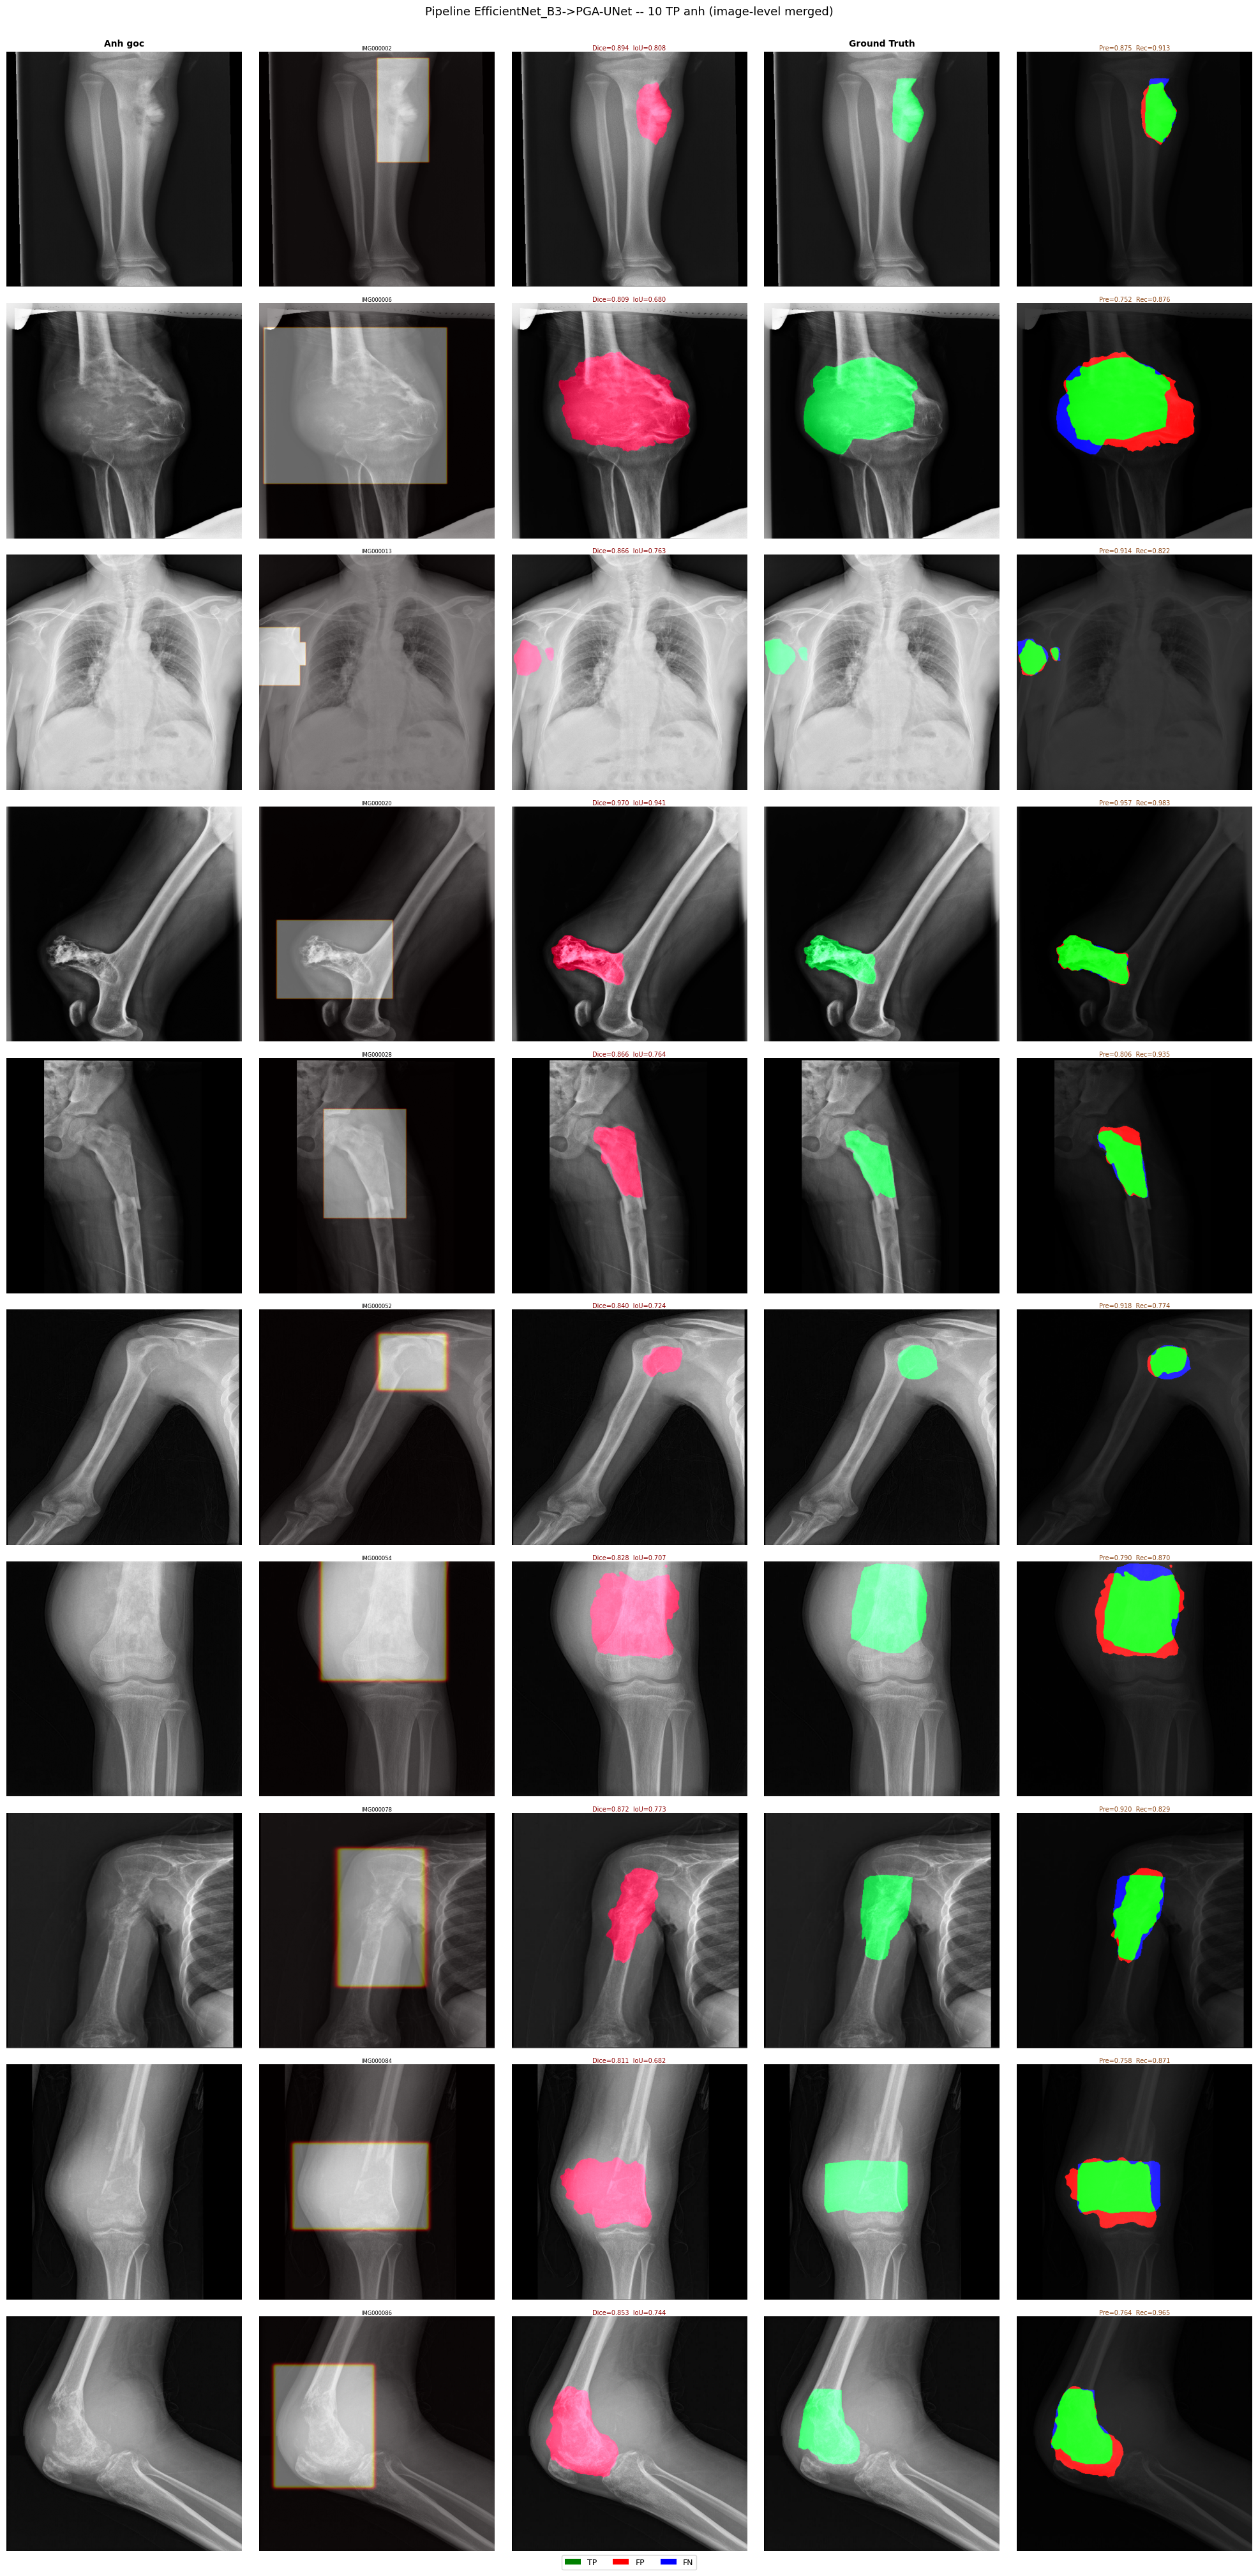

OK Saved: results/pipeline_vis_tp.png


In [12]:
# ── Cell 8: Visualization -- TP cases (image-level merged) ──────────────────────
# Chay sau cell 5. Re-run PGA inference per-image (max-merge polygons).
import matplotlib.pyplot as plt
import numpy as np, cv2, os
from matplotlib.patches import Patch
from IPython.display import display as _ipy_display

N_SHOW = 10   # so TP anh hien thi

tp_images = [r for r in results if r['seg_status'] == 'TP'][:N_SHOW]
assert tp_images, 'Khong co TP -- chay cell 5 truoc'

vis_records = []
with torch.no_grad():
    for r in tp_images:
        base     = r['sample']
        img_file = next((f for f in os.listdir(IMG_DIR)
                         if os.path.splitext(f)[0] == base), None)
        if not img_file: continue
        img_path = os.path.join(IMG_DIR, img_file)
        jsn_path = os.path.join(JSON_DIR, base + '.json')
        polygons = load_polygons(jsn_path)
        if not polygons: continue

        gt_union   = np.zeros((SEG_IMG_SIZE, SEG_IMG_SIZE), dtype=np.float32)
        prob_max   = np.zeros((SEG_IMG_SIZE, SEG_IMG_SIZE), dtype=np.float32)
        prompts    = []
        img_tensor = preprocess_seg(img_path)

        for pts in polygons:
            hm_t    = polygon_heatmap(pts, img_path, S=SEG_IMG_SIZE)
            prob_np = torch.sigmoid(seg_model(img_tensor, hm_t))[0, 0].cpu().numpy()
            gt_np   = polygon_gt_mask(pts, img_path, S=SEG_IMG_SIZE)
            np.maximum(gt_union, gt_np,   out=gt_union)
            np.maximum(prob_max, prob_np, out=prob_max)
            prompts.append(hm_t[0, 0].cpu().numpy())

        img_gray = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        img_gray = cv2.resize(img_gray, (SEG_IMG_SIZE, SEG_IMG_SIZE)).astype(np.float32) / 255.
        vis_records.append(dict(img_name=base, img=img_gray, gt=gt_union,
                                prob=prob_max, prompts=prompts, n_poly=len(polygons)))

N_ACTUAL = len(vis_records)
fig, axes = plt.subplots(N_ACTUAL, 5, figsize=(20, 4 * N_ACTUAL))
if N_ACTUAL == 1:
    axes = axes[np.newaxis, :]
fig.suptitle(f'Pipeline EfficientNet_B3->PGA-UNet -- {N_ACTUAL} TP anh (image-level merged)',
             fontsize=13, y=1.001)

col_titles = ['Anh goc', 'Anh + Prompts', 'Du doan (merged)', 'Ground Truth', 'TP/FP/FN']
for ax, ct in zip(axes[0], col_titles):
    ax.set_title(ct, fontsize=10, fontweight='bold')

eps = 1e-6
for count, rec in enumerate(vis_records):
    img_np  = rec['img']
    gt_np   = (rec['gt']   > 0.5).astype(float)
    pred_np = (rec['prob'] > 0.5).astype(float)
    pm_merged = np.max(np.stack(rec['prompts'], 0), 0)
    n         = rec['n_poly']

    tp_ = (pred_np * gt_np).sum(); fp_ = (pred_np * (1 - gt_np)).sum()
    fn_ = ((1 - pred_np) * gt_np).sum()
    dice = float((2*tp_+eps)/(2*tp_+fp_+fn_+eps))
    iou  = float((tp_+eps)/(tp_+fp_+fn_+eps))
    pre  = (float(tp_/(tp_+fp_)) if (tp_+fp_)>0 else 0.)
    rec_ = float((tp_+eps)/(tp_+fn_+eps))

    row = axes[count]
    bg  = np.stack([img_np] * 3, axis=-1)

    row[0].imshow(img_np, cmap='gray', vmin=0, vmax=1)
    row[0].set_ylabel(f'#{count+1} [{n} poly]\nDice={dice:.3f}', fontsize=8)

    row[1].imshow(img_np, cmap='gray', vmin=0, vmax=1)
    row[1].imshow(pm_merged, cmap='hot', alpha=0.4, vmin=0, vmax=1)
    row[1].set_title(rec['img_name'], fontsize=6, pad=2)

    pr_ov = bg.copy()
    pr_ov[..., 0] = np.clip(pr_ov[..., 0] + pred_np * 0.55, 0, 1)
    pr_ov[..., 1] = np.clip(pr_ov[..., 1] - pred_np * 0.2,  0, 1)
    row[2].imshow(pr_ov)
    row[2].set_title(f'Dice={dice:.3f}  IoU={iou:.3f}', fontsize=7, color='darkred', pad=2)

    gt_ov = bg.copy()
    gt_ov[..., 1] = np.clip(gt_ov[..., 1] + gt_np * 0.55, 0, 1)
    gt_ov[..., 0] = np.clip(gt_ov[..., 0] - gt_np * 0.2,  0, 1)
    row[3].imshow(gt_ov)

    inter = bg.copy() * 0.25
    inter[..., 1] = np.clip(inter[..., 1] + pred_np * gt_np       * 0.9, 0, 1)
    inter[..., 0] = np.clip(inter[..., 0] + pred_np * (1 - gt_np) * 1.0, 0, 1)
    inter[..., 2] = np.clip(inter[..., 2] + (1 - pred_np) * gt_np * 1.0, 0, 1)
    row[4].imshow(inter)
    row[4].set_title(f'Pre={pre:.3f}  Rec={rec_:.3f}', fontsize=7, color='saddlebrown', pad=2)

    for ax in row:
        ax.axis('off')

fig.legend(
    handles=[Patch(facecolor='green', label='TP'),
             Patch(facecolor='red',   label='FP'),
             Patch(facecolor='blue',  label='FN')],
    loc='lower center', ncol=3, fontsize=9, bbox_to_anchor=(0.5, -0.005)
)
plt.tight_layout()
plt.savefig('results/pipeline_vis_tp.png', dpi=120, bbox_inches='tight')
_ipy_display(fig)
plt.close(fig)
print(f'OK Saved: results/pipeline_vis_tp.png')